# ChatGPT 與 Gemini 焦點貼文之情緒比較

Objective:
- 以 `content` 中是否提到 `ChatGPT` / `Gemini` 為基礎，建立 `ChatGPT only / Gemini only / Both` 三類貼文。
- 比較 `ChatGPT only` 與 `Gemini only` 的整體情緒差異。
- 使用 `VADER` 計算 `compound / pos / neu / neg`，作為貼文情緒指標。
- 將 `Both` 類貼文留作補充分析，因其更接近「比較或選擇模型」的討論情境。


In [1]:
from __future__ import annotations

from pathlib import Path
import textwrap

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "chatgpt_subreddit.csv").exists() and (candidate / "googlegemini_subreddit.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
RAW_PATHS = [
    PROJECT_ROOT / "chatgpt_subreddit.csv",
    PROJECT_ROOT / "googlegemini_subreddit.csv",
]
MODEL_FOCUS_DIR = PROJECT_ROOT / "output" / "model-focus"
OUTPUT_DIR = PROJECT_ROOT / "output" / "jupyter-notebook"
MODEL_FOCUS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

POSITIVE_THRESHOLD = 0.05
NEGATIVE_THRESHOLD = -0.05
CHATGPT_PATTERN = r"\bchat\s*gpt\b|\bchatgpt\b"
GEMINI_PATTERN = r"\bgemini\b"
analyzer = SentimentIntensityAnalyzer()

{
    "raw_paths": [str(path) for path in RAW_PATHS],
    "model_focus_dir": str(MODEL_FOCUS_DIR),
    "output_dir": str(OUTPUT_DIR),
    "figures_dir": str(FIGURES_DIR),
}


{'raw_paths': ['/Users/chenqien/Documents/碩一下/社群媒體分析/第一次讀書會專案/chatgpt_subreddit.csv',
  '/Users/chenqien/Documents/碩一下/社群媒體分析/第一次讀書會專案/googlegemini_subreddit.csv'],
 'model_focus_dir': '/Users/chenqien/Documents/碩一下/社群媒體分析/第一次讀書會專案/output/model-focus',
 'output_dir': '/Users/chenqien/Documents/碩一下/社群媒體分析/第一次讀書會專案/output/jupyter-notebook',
 'figures_dir': '/Users/chenqien/Documents/碩一下/社群媒體分析/第一次讀書會專案/output/jupyter-notebook/figures'}

## Plan

- Data build:
  合併兩份原始 CSV，依 `content` 判斷是否提到 `ChatGPT` / `Gemini`。
- Classification rule:
  分類只看 `content`，不使用 `search_keyword` 或 `source_subreddit` 當標籤。
- Main analysis:
  `ChatGPT only` 與 `Gemini only` 比較整體情緒，避免雙模型貼文混入主比較。
- Supplemental analysis:
  `Both` 類單獨呈現，並額外檢查 2025-03 至 2025-04 的樣本內容。
- Metrics:
  觀察 `compound` 平均值、中位數，以及 `positive / neutral / negative` 比例。


In [2]:
raw_frames = []
for raw_path in RAW_PATHS:
    frame = pd.read_csv(raw_path).copy()
    frame["source_file"] = raw_path.name
    frame["row_in_file"] = range(1, len(frame) + 1)
    raw_frames.append(frame)

all_posts = pd.concat(raw_frames, ignore_index=True)
all_posts["artDate"] = pd.to_datetime(all_posts["artDate"], errors="coerce")
all_posts["score"] = pd.to_numeric(all_posts["score"], errors="coerce")
all_posts["num_comments"] = pd.to_numeric(all_posts["num_comments"], errors="coerce")
all_posts["content"] = (
    all_posts["content"]
    .fillna("")
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
all_posts["mentions_chatgpt"] = all_posts["content"].str.contains(
    CHATGPT_PATTERN, case=False, regex=True
).astype(int)
all_posts["mentions_gemini"] = all_posts["content"].str.contains(
    GEMINI_PATTERN, case=False, regex=True
).astype(int)
all_posts["model_focus"] = "Neither"
all_posts.loc[
    (all_posts["mentions_chatgpt"] == 1) & (all_posts["mentions_gemini"] == 0),
    "model_focus",
] = "ChatGPT only"
all_posts.loc[
    (all_posts["mentions_chatgpt"] == 0) & (all_posts["mentions_gemini"] == 1),
    "model_focus",
] = "Gemini only"
all_posts.loc[
    (all_posts["mentions_chatgpt"] == 1) & (all_posts["mentions_gemini"] == 1),
    "model_focus",
] = "Both"
all_posts["month"] = all_posts["artDate"].dt.to_period("M").dt.to_timestamp()

ordered_columns = [
    "source_file",
    "row_in_file",
    "model_focus",
    "mentions_chatgpt",
    "mentions_gemini",
    "artDate",
    "content",
    "score",
    "num_comments",
    "url",
    "source_subreddit",
    "search_keyword",
]
all_posts = all_posts.loc[:, ordered_columns + ["month"]]

duplicate_url_rows = int(all_posts["url"].duplicated(keep=False).sum())
unique_url_count = all_posts["url"].nunique(dropna=True)

main_posts = all_posts.loc[all_posts["model_focus"].isin(["ChatGPT only", "Gemini only"])].copy()
both_posts = all_posts.loc[all_posts["model_focus"] == "Both"].copy()
neither_posts = all_posts.loc[all_posts["model_focus"] == "Neither"].copy()

overview = (
    all_posts.groupby("model_focus")
    .agg(
        posts=("content", "size"),
        avg_score=("score", "mean"),
        avg_comments=("num_comments", "mean"),
    )
    .sort_index()
)

subreddit_mix = (
    main_posts.groupby(["model_focus", "source_subreddit"])
    .size()
    .rename("posts")
    .reset_index()
    .sort_values(["model_focus", "posts"], ascending=[True, False])
)

focus_order = ["Both", "ChatGPT only", "Gemini only", "Neither"]
summary_rows = [
    {
        "group_type": "overall",
        "group_name": "all_rows",
        "model_focus": label,
        "posts": int((all_posts["model_focus"] == label).sum()),
    }
    for label in focus_order
]
for source_file, group in all_posts.groupby("source_file"):
    for label in focus_order:
        summary_rows.append(
            {
                "group_type": "source_file",
                "group_name": source_file,
                "model_focus": label,
                "posts": int((group["model_focus"] == label).sum()),
            }
        )
model_focus_summary = pd.DataFrame(summary_rows)

all_posts.loc[:, ordered_columns].to_csv(MODEL_FOCUS_DIR / "model_focus_all_posts.csv", index=False)
main_posts.loc[main_posts["model_focus"] == "ChatGPT only", ordered_columns].to_csv(
    MODEL_FOCUS_DIR / "model_focus_chatgpt_only_posts.csv", index=False
)
main_posts.loc[main_posts["model_focus"] == "Gemini only", ordered_columns].to_csv(
    MODEL_FOCUS_DIR / "model_focus_gemini_only_posts.csv", index=False
)
both_posts.loc[:, ordered_columns].to_csv(MODEL_FOCUS_DIR / "model_focus_both_posts.csv", index=False)
neither_posts.loc[:, ordered_columns].to_csv(
    MODEL_FOCUS_DIR / "model_focus_neither_posts.csv", index=False
)
main_posts.loc[main_posts["model_focus"] == "ChatGPT only", ordered_columns].to_csv(
    MODEL_FOCUS_DIR / "chatgpt_only.csv", index=False
)
main_posts.loc[main_posts["model_focus"] == "Gemini only", ordered_columns].to_csv(
    MODEL_FOCUS_DIR / "gemini_only.csv", index=False
)
both_posts.loc[:, ordered_columns].to_csv(MODEL_FOCUS_DIR / "both.csv", index=False)
model_focus_summary.to_csv(MODEL_FOCUS_DIR / "model_focus_summary.csv", index=False)

display(Markdown("## 資料概況"))
display(
    pd.DataFrame(
        [
            {
                "raw_rows": len(all_posts),
                "unique_urls": unique_url_count,
                "duplicate_url_rows": duplicate_url_rows,
            }
        ]
    )
)
display(overview)
display(Markdown("### 主分析樣本的 source_subreddit 分布"))
display(subreddit_mix)


## 資料概況

,raw_rows,unique_urls,duplicate_url_rows
0,1418,1056,697


,posts,avg_score,avg_comments
model_focus,,,
Both,560,2.400,2.161
ChatGPT only,469,6.147,4.198
Gemini only,389,1.098,0.933


### 主分析樣本的 source_subreddit 分布

,model_focus,source_subreddit,posts
0,ChatGPT only,ChatGPT,469
1,Gemini only,ChatGPT,267
2,Gemini only,GoogleGemini,122


## 方法說明

- 原始檔 `chatgpt_subreddit.csv` 與 `googlegemini_subreddit.csv` 是兩批看板貼文集合，不是模型 `only` 資料集。
- 兩份原始 CSV 先合併，再依 `content` 是否提到 `ChatGPT` / `Gemini` 進行分類。
- 分類定義：
  `ChatGPT only` = 貼文提到 `ChatGPT`，且沒有提到 `Gemini`。
  `Gemini only` = 貼文提到 `Gemini`，且沒有提到 `ChatGPT`。
  `Both` = 同一篇貼文同時提到 `ChatGPT` 與 `Gemini`。
- `search_keyword` 與 `source_subreddit` 只當 metadata，不直接作為分類依據。
- 本 notebook 的主分析只使用 `ChatGPT only` 和 `Gemini only`。
- `Both` 類貼文會另做補充，不直接拿來代表單一模型情緒。
- 目前保留原始貼文列，不做 URL 去重；若要做「唯一貼文」分析，需另開 dedup 版流程。


In [3]:
def score_text(text: str) -> pd.Series:
    return pd.Series(analyzer.polarity_scores(text))


vader_scores = main_posts["content"].apply(score_text)
main_posts = pd.concat([main_posts, vader_scores], axis=1)


def label_from_compound(value: float) -> str:
    if value >= POSITIVE_THRESHOLD:
        return "positive"
    if value <= NEGATIVE_THRESHOLD:
        return "negative"
    return "neutral"


main_posts["sentiment_label"] = main_posts["compound"].apply(label_from_compound)
main_posts["content_preview"] = main_posts["content"].apply(
    lambda text: textwrap.shorten(text, width=180, placeholder="...")
)

main_posts.head(10)


,source_file,row_in_file,model_focus,mentions_chatgpt,mentions_gemini,artDate,content,score,num_comments,url,source_subreddit,search_keyword,month,neg,neu,pos,compound,sentiment_label,content_preview
0,chatgpt_subreddit.csv,1,ChatGPT only,1,0,2025-05-19,Why chatgpt has to be like this,1,1,https://www.reddit.com/r/ChatGPT/comments/1kqaz92/why_chatgpt_has_to_be_like_this/,ChatGPT,ChatGPT,2025-05-01,0.000,0.706,0.294,0.361,positive,Why chatgpt has to be like this
1,chatgpt_subreddit.csv,2,ChatGPT only,1,0,2025-05-19,"For a change, this is about deepseek gone wild Hi for the first time Deepseek is acting weird !!!!! I have attached the screenshot for more information. I a...",1,1,https://www.reddit.com/r/ChatGPT/comments/1kqax4u/for_a_change_this_is_about_deepseek_gone_wild/,ChatGPT,ChatGPT,2025-05-01,0.099,0.867,0.034,-0.701,negative,"For a change, this is about deepseek gone wild Hi for the first time Deepseek is acting weird !!!!! I have attached the screenshot for more information. I a..."
2,chatgpt_subreddit.csv,3,ChatGPT only,1,0,2025-05-19,Hey this is about Deepseek for a change! I wanna know if chatgpt users have encountered something like this ? Hi for the first time since I started using De...,1,1,https://www.reddit.com/r/ChatGPT/comments/1kqatk6/hey_this_is_about_deepseek_for_a_change/,ChatGPT,ChatGPT,2025-05-01,0.098,0.871,0.032,-0.737,negative,Hey this is about Deepseek for a change! I wanna know if chatgpt users have encountered something like this ? Hi for the first time since I started using De...
3,chatgpt_subreddit.csv,4,ChatGPT only,1,0,2025-05-19,Havent used chatGPT both on my computer and phone and I have these notifications for the last 18hrs. What does this mean?,1,2,https://www.reddit.com/r/ChatGPT/comments/1kqajge/havent_used_chatgpt_both_on_my_computer_and_phone/,ChatGPT,ChatGPT,2025-05-01,0.000,1.000,0.000,0.000,neutral,Havent used chatGPT both on my computer and phone and I have these notifications for the last 18hrs. What does this mean?
4,chatgpt_subreddit.csv,5,ChatGPT only,1,0,2025-05-19,"Will chatgpt really respond back after 15-30 minutes? 🤔 This is the first time I have encountered such a response. For context, I have been chatting with Ch...",1,1,https://www.reddit.com/r/ChatGPT/comments/1kq9np7/will_chatgpt_really_respond_back_after_1530/,ChatGPT,ChatGPT,2025-05-01,0.000,0.928,0.072,0.694,positive,"Will chatgpt really respond back after 15-30 minutes? 🤔 This is the first time I have encountered such a response. For context, I have been chatting with Ch..."
5,chatgpt_subreddit.csv,6,ChatGPT only,1,0,2025-05-19,Chatgpt policy sucks [removed],1,1,https://www.reddit.com/r/ChatGPT/comments/1kq9fmp/chatgpt_policy_sucks/,ChatGPT,ChatGPT,2025-05-01,0.455,0.545,0.000,-0.361,negative,Chatgpt policy sucks [removed]
6,chatgpt_subreddit.csv,7,ChatGPT only,1,0,2025-05-19,"Just curious... do you guys prefer using ChatGPT or Google for searching? For me, I generally prefer ChatGPT because it can give you specific answers and it...",1,1,https://www.reddit.com/r/ChatGPT/comments/1kq7p5w/just_curious_do_you_guys_prefer_using_chatgpt_or/,ChatGPT,ChatGPT,2025-05-01,0.028,0.779,0.194,0.955,positive,"Just curious... do you guys prefer using ChatGPT or Google for searching? For me, I generally prefer ChatGPT because it can give you specific answers and it..."
7,chatgpt_subreddit.csv,8,ChatGPT only,1,0,2025-05-19,First time using the Canvas feature. Are you for real? What's the point of the Canvas feature if it can't do this? Or is ChatGPT just glitching out?,1,1,https://www.reddit.com/r/ChatGPT/comments/1kq7dbw/first_time_using_the_canvas_feature_are_you_for/,ChatGPT,ChatGPT,2025-05-01,0.000,1.000,0.000,0.000,neutral,First time using the Canvas feature. Are you for real? What's the point of the Canvas feature if it can't do this? Or is ChatGPT just glitching out?
8,chatgpt_subreddit.csv,9,ChatGPT only,1,0,2025-05-19,What Tf do they train their model with? Literally just wanted a day 1 poster to show motivate me to con

In [4]:
sentiment_summary = (
    main_posts.groupby("model_focus")
    .agg(
        posts=("content", "size"),
        mean_compound=("compound", "mean"),
        median_compound=("compound", "median"),
        std_compound=("compound", "std"),
        positive_share=("sentiment_label", lambda values: (values == "positive").mean()),
        neutral_share=("sentiment_label", lambda values: (values == "neutral").mean()),
        negative_share=("sentiment_label", lambda values: (values == "negative").mean()),
        avg_score=("score", "mean"),
        avg_comments=("num_comments", "mean"),
    )
    .sort_index()
)

sentiment_distribution = (
    main_posts.groupby(["model_focus", "sentiment_label"])
    .size()
    .rename("posts")
    .reset_index()
)
sentiment_distribution["share"] = sentiment_distribution.groupby("model_focus")["posts"].transform(
    lambda values: values / values.sum()
)

monthly_summary = (
    main_posts.groupby(["month", "model_focus"])
    .agg(
        posts=("content", "size"),
        mean_compound=("compound", "mean"),
        negative_share=("sentiment_label", lambda values: (values == "negative").mean()),
    )
    .reset_index()
    .sort_values(["month", "model_focus"])
)

main_posts.to_csv(OUTPUT_DIR / "vader_model_focus_scored_posts.csv", index=False)
sentiment_summary.to_csv(OUTPUT_DIR / "vader_model_focus_summary.csv")
sentiment_distribution.to_csv(OUTPUT_DIR / "vader_model_focus_distribution.csv", index=False)
monthly_summary.to_csv(OUTPUT_DIR / "vader_model_focus_monthly_summary.csv", index=False)

display(Markdown("## 主分析摘要"))
display(sentiment_summary)
display(Markdown("### 情緒標籤分布"))
display(sentiment_distribution.sort_values(["model_focus", "sentiment_label"]))


## 主分析摘要

,posts,mean_compound,median_compound,std_compound,positive_share,neutral_share,negative_share,avg_score,avg_comments
model_focus,,,,,,,,,
ChatGPT only,469,0.264,0.340,0.570,0.580,0.209,0.211,6.147,4.198
Gemini only,389,0.327,0.402,0.525,0.576,0.239,0.185,1.098,0.933


### 情緒標籤分布

,model_focus,sentiment_label,posts,share
0,ChatGPT only,negative,99,0.211
1,ChatGPT only,neutral,98,0.209
2,ChatGPT only,positive,272,0.580
3,Gemini only,negative,72,0.185
4,Gemini only,neutral,93,0.239
5,Gemini only,positive,224,0.576


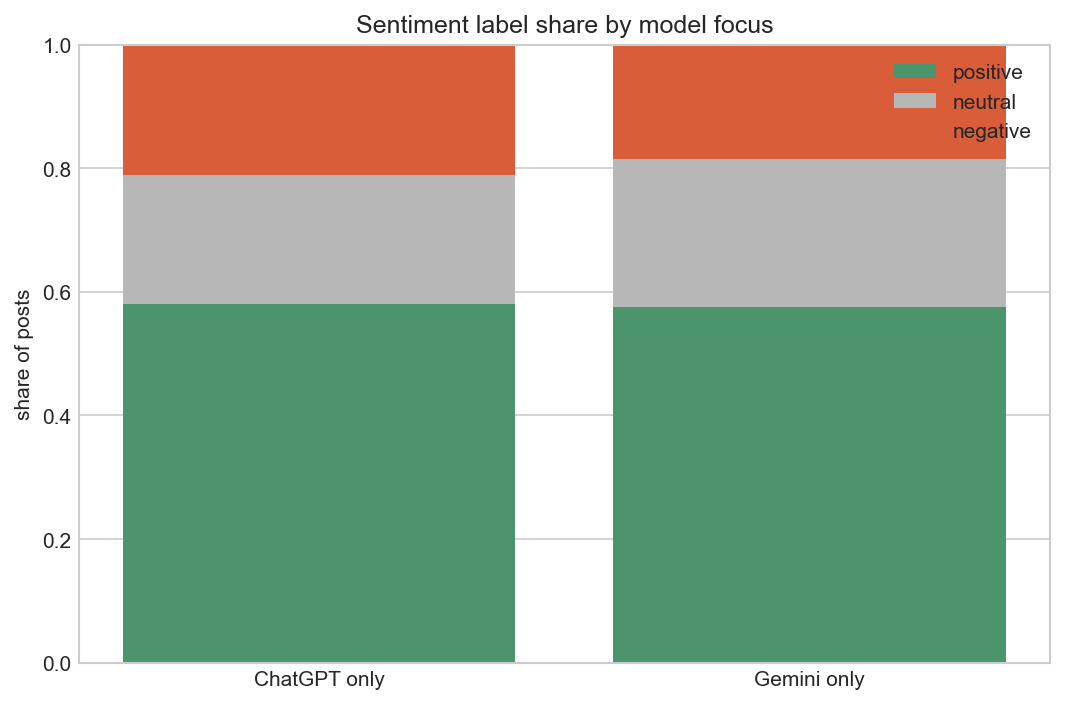

In [5]:
distribution_plot = (
    sentiment_distribution.pivot(index="model_focus", columns="sentiment_label", values="share")
    .reindex(columns=["positive", "neutral", "negative"])
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(7.2, 4.8), dpi=150)
bottom = pd.Series([0.0] * len(distribution_plot), index=distribution_plot.index)
colors = {"positive": "#4C956C", "neutral": "#B7B7B7", "negative": "#D95D39"}

for label in ["positive", "neutral", "negative"]:
    values = distribution_plot[label]
    ax.bar(distribution_plot.index, values, bottom=bottom, label=label, color=colors[label])
    bottom = bottom + values

ax.set_ylim(0, 1)
ax.set_ylabel("share of posts")
ax.set_title("Sentiment label share by model focus")
ax.legend(loc="upper right")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "vader_model_focus_label_share.png", bbox_inches="tight")
plt.show()


/var/folders/hz/rkgx10wj74j9dswg6f028cdh0000gn/T/ipykernel_74080/2337649348.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


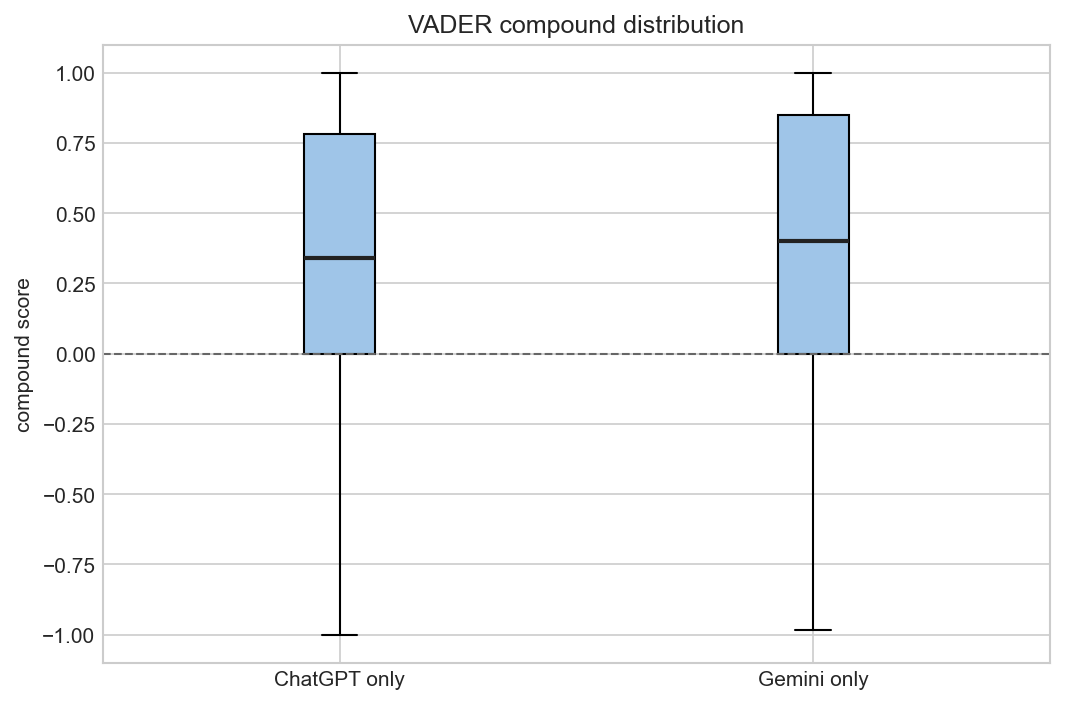

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 4.8), dpi=150)
data = [main_posts.loc[main_posts["model_focus"] == label, "compound"] for label in ["ChatGPT only", "Gemini only"]]
ax.boxplot(
    data,
    labels=["ChatGPT only", "Gemini only"],
    patch_artist=True,
    boxprops={"facecolor": "#9FC5E8"},
    medianprops={"color": "#222222", "linewidth": 2},
)
ax.axhline(0, linestyle="--", linewidth=1, color="#666666")
ax.set_ylabel("compound score")
ax.set_title("VADER compound distribution")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "vader_model_focus_compound_boxplot.png", bbox_inches="tight")
plt.show()


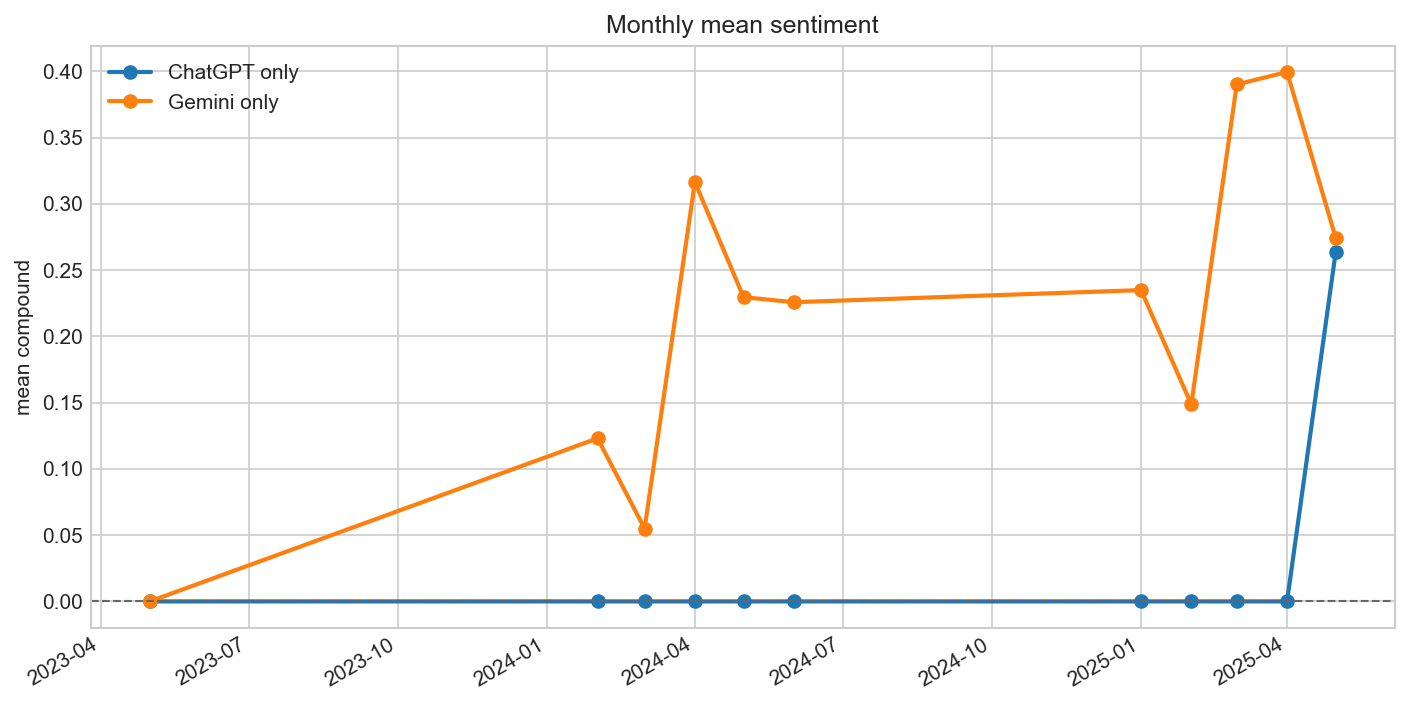

In [7]:
trend_plot = monthly_summary.pivot(index="month", columns="model_focus", values="mean_compound").fillna(0)

fig, ax = plt.subplots(figsize=(9.5, 4.8), dpi=150)
for label in trend_plot.columns:
    ax.plot(trend_plot.index, trend_plot[label], marker="o", linewidth=2, label=label)

ax.axhline(0, linestyle="--", linewidth=1, color="#666666")
ax.set_ylabel("mean compound")
ax.set_title("Monthly mean sentiment")
ax.legend(loc="upper left")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "vader_model_focus_monthly_mean_compound.png", bbox_inches="tight")
plt.show()


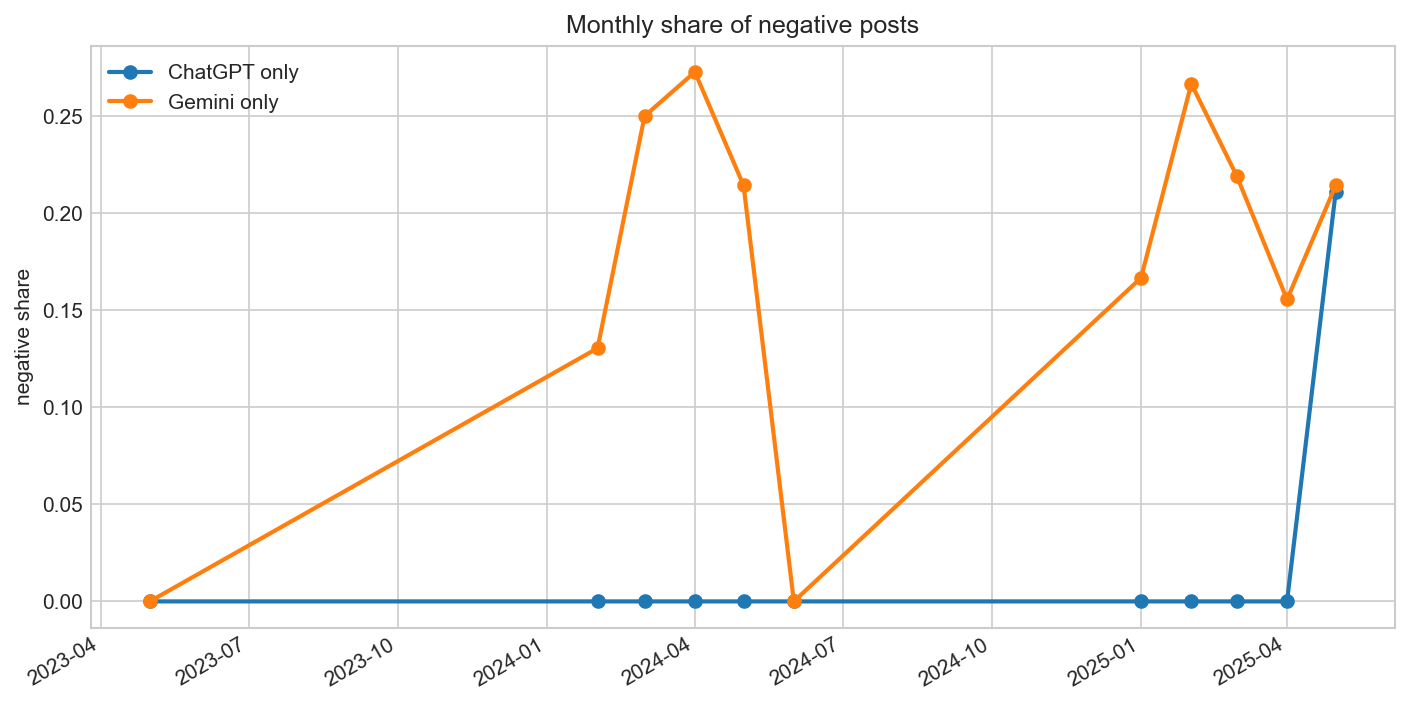

In [8]:
negative_plot = monthly_summary.pivot(index="month", columns="model_focus", values="negative_share").fillna(0)

fig, ax = plt.subplots(figsize=(9.5, 4.8), dpi=150)
for label in negative_plot.columns:
    ax.plot(negative_plot.index, negative_plot[label], marker="o", linewidth=2, label=label)

ax.set_ylabel("negative share")
ax.set_title("Monthly share of negative posts")
ax.legend(loc="upper left")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "vader_model_focus_monthly_negative_share.png", bbox_inches="tight")
plt.show()


## 解讀提醒

- 依目前規則，`ChatGPT only` 的條件是：貼文提到 `ChatGPT`，且 **沒有** 提到 `Gemini`。
- 因此，`ChatGPT only` 集中在 2025-05，不代表更早沒有 GPT/OpenAI 相關討論；較早期貼文若同時提到 `Gemini`，就會被歸到 `Both`。
- 若研究問題是「使用者在不同場景下如何比較或選擇 ChatGPT / Gemini」，`Both` 類貼文其實更接近決策情境，但不能直接用整篇貼文的單一情緒值代表對某一模型的態度。


In [9]:
both_unique = both_posts.sort_values(["url", "source_file", "row_in_file"]).drop_duplicates("url", keep="first").copy()
both_2025_03_04 = both_unique.loc[
    (both_unique["artDate"] >= "2025-03-01") & (both_unique["artDate"] < "2025-05-01")
].copy()
both_2025_03_04["month"] = both_2025_03_04["artDate"].dt.to_period("M").astype(str)

both_2025_03_04_counts = (
    both_2025_03_04["month"]
    .value_counts()
    .sort_index()
    .rename("unique_both_posts")
    .to_frame()
)

both_manual_parts = []
for month in ["2025-03", "2025-04"]:
    month_frame = both_2025_03_04.loc[both_2025_03_04["month"] == month].copy()
    if len(month_frame) == 0:
        continue
    both_manual_parts.append(
        month_frame.sample(n=min(5, len(month_frame)), random_state=42)
    )

both_manual_sample = (
    pd.concat(both_manual_parts, ignore_index=True)
    .sort_values(["month", "artDate", "row_in_file"])
    .reset_index(drop=True)
)
both_manual_sample["content_preview"] = both_manual_sample["content"].apply(
    lambda text: textwrap.shorten(text, width=150, placeholder="...")
)

display(Markdown("## 補充檢查：2025-03 至 2025-04 的 Both"))
display(Markdown("以下先以 unique URL 去重，再從 2025-03 與 2025-04 各抽樣 5 篇作人工檢查。"))
display(both_2025_03_04_counts)
display(
    both_manual_sample.loc[
        :,
        ["month", "artDate", "source_subreddit", "search_keyword", "url", "content_preview"],
    ]
)


## 補充檢查：2025-03 至 2025-04 的 Both

以下先以 unique URL 去重，再從 2025-03 與 2025-04 各抽樣 5 篇作人工檢查。

,unique_both_posts
month,
2025-03,34
2025-04,171


,month,artDate,source_subreddit,search_keyword,url,content_preview
0,2025-03,2025-03-25,ChatGPT,Gemini,https://www.reddit.com/r/ChatGPT/comments/1jjwq7b/does_anyone_use_different_chat_apps_for_different/,Does anyone use different chat apps for different things or does everyone just use ChatGPT? I find myself mostly using ChatGPT whenever I want to...
1,2025-03,2025-03-27,ChatGPT,Gemini,https://www.reddit.com/r/ChatGPT/comments/1jl9uz8/which_ai_has_the_best_free_image_generator/,Which Ai has the best Free Image Generator currently? PROMPT: &gt; &gt; &gt; &gt; Gemini: [https://media-...
2,2025-03,2025-03-28,ChatGPT,Gemini,https://www.reddit.com/r/ChatGPT/comments/1jlkwwn/i_scraped_31_million_jobs_with_chatgpt/,I scraped 3.1 million jobs with ChatGPT I'm sick and tired of how LinkedIn &amp; Indeed is contaminated with ghost jobs and 3rd party offshore...
3,2025-03,2025-03-29,ChatGPT,Gemini,https://www.reddit.com/r/ChatGPT/comments/1jmzttp/best_llm_free_or_paid_for_resumecover_letter/,Best LLM (free or paid) for resume/cover letter writing? Been applying for months to various entry level positions and never get anything back. I...
4,2025-03,2025-03-29,ChatGPT,Gemini,https://www.reddit.com/r/ChatGPT/comments/1jmydqi/any_recommendations/,"Any recommendations? What is the best Al subscription to make for writing essays, which may involve uploading numerous files like pdfs, images etc?..."
5,2025-04,2025-04-11,ChatGPT,Gemini,https://www.reddit.com/r/ChatGPT/comments/1jx32s9/gpt4o_is_great_but_gemini_25_pro_is_on_a_whole/,"GPT-4o is great, but Gemini 2.5 Pro is on a whole other level Whenever I need a quick answer (a Google replacement) I head to ChatGPT because it's..."
6,2025-04,2025-04-11,ChatGPT,Gemini,https://www.reddit.com/r/ChatGPT/comments/1jwzvwz/what_happens_when_you_ask_six_ai_models_the_same/,"What happens when you ask six AI models the same question independently? 🧠 One human. Six AIs. One truth. I asked the same question to ChatGPT,..."
7,2025-04,2025-04-19,ChatGPT,Gemini,https://www.reddit.com/r/ChatGPT/comments/1k35ndw/anyone_else_experiencedfrustrated_with_chatgpt/,Anyone else experienced/frustrated with ChatGPT revert to robotic phase? Perhaps it's just me. My GPT and I have built this unique way of...
8,2025-04,2025-04-26,ChatGPT,Gemini,https://www.reddit.com/r/ChatGPT/comments/1k81qtk/does_anyone_else_find_it_ironic_that_chatgpt/,Does anyone else find it ironic that ChatGPT doesn't know it's own current API documentation? I've built many apps utilizing the openai api with...
9,2025-04,2025-04-29,ChatGPT,Gemini,https://www.reddit.com/r/ChatGPT/comments/1kald75/i_think_i_will_switch_to_gemini/,I think I will switch to Gemini? I am a longtime ChatGPT user and bought ChatGPT Plus as soon as it came out. I was consistently impressed by the...


補充說明：

- 這批 2025-03 至 2025-04 的 `Both` 抽樣貼文，多數屬於直接比較、切換、選擇或 benchmark 情境，例如比較 `ChatGPT` 與 `Gemini` 的表現、詢問該用哪一個模型、或描述從一個模型轉向另一個模型。
- 因此，早期月份不是沒有 `ChatGPT` 相關貼文，而是這些貼文往往同時提到 `Gemini`，所以在目前規則下會被歸類到 `Both`。


In [10]:
both_scores = both_posts["content"].apply(score_text)
both_posts = pd.concat([both_posts, both_scores], axis=1)
both_posts["sentiment_label"] = both_posts["compound"].apply(label_from_compound)

both_summary = pd.Series(
    {
        "posts": len(both_posts),
        "mean_compound": both_posts["compound"].mean(),
        "median_compound": both_posts["compound"].median(),
        "positive_share": (both_posts["sentiment_label"] == "positive").mean(),
        "neutral_share": (both_posts["sentiment_label"] == "neutral").mean(),
        "negative_share": (both_posts["sentiment_label"] == "negative").mean(),
    }
)
both_summary_df = both_summary.to_frame().T
both_summary_df.index = ["Both"]
both_summary_df.index.name = "model_focus"

both_posts.to_csv(OUTPUT_DIR / "vader_both_scored_posts.csv", index=False)
both_summary_df.to_csv(OUTPUT_DIR / "vader_both_summary.csv")

display(Markdown("## 補充分析：Both"))
both_summary_df


## 補充分析：Both

,posts,mean_compound,median_compound,positive_share,neutral_share,negative_share
model_focus,,,,,,
Both,560.000,0.468,0.703,0.711,0.136,0.154


In [11]:
representative_posts = (
    main_posts.loc[:, ["model_focus", "artDate", "compound", "score", "num_comments", "url", "content_preview"]]
    .sort_values(["model_focus", "compound", "num_comments"], ascending=[True, False, False])
    .groupby("model_focus")
    .head(5)
    .reset_index(drop=True)
)

display(Markdown("## 代表性高情緒貼文"))
display(representative_posts)


## 代表性高情緒貼文

,model_focus,artDate,compound,score,num_comments,url,content_preview
0,ChatGPT only,2025-05-13,1.000,1,1,https://www.reddit.com/r/ChatGPT/comments/1klatxg/inspired_by_previous_similar_post_got_diviningai/,(Inspired by previous similar post) Got DiviningAI to 'deep research' and conjecture a sermon from Jesus today. DiviningAI presumes as fact that no leaf fal...
1,ChatGPT only,2025-05-14,1.000,1,1,https://www.reddit.com/r/ChatGPT/comments/1kmi836/explaining_repeating_images_characters_the_oil/,Explaining Repeating images &amp; Characters ---The oil painting of a woman with / wearing flowers. So not long ago there was a thread with dozens and dozen...
2,ChatGPT only,2025-05-15,0.999,1,1,https://www.reddit.com/r/ChatGPT/comments/1knjhv6/conversation_i_just_had_with_my_chatgpt/,"Conversation I just had with my chatGPT Me: What do you, as an AI, think when somebody is generating a prompt that is illegal, immoral, offensive or obscene..."
3,ChatGPT only,2025-05-12,0.999,1,1,https://www.reddit.com/r/ChatGPT/comments/1kkn3vb/chatgpts_plan_to_empower_the_povertystricken/,ChatGPT's Plan to Empower the Poverty-Stricken https://preview.redd.it/p3zaa4fa6b0f1.png?width=658&amp;format=png&amp;auto=webp&amp;s=21ac9e13631d91cb27c61f...
4,ChatGPT only,2025-05-17,0.999,1,1,https://www.reddit.com/r/ChatGPT/comments/1kogrkm/chatgpt_keeps_telling_me_about_the_weather_in/,"ChatGPT keeps telling me about the weather in Cambridge? Hey guys, I think I've come across a bug. I asked ChatGPT to help me with reading an RTF file becau..."
5,Gemini only,2024-04-20,1.000,1,0,https://www.reddit.com/r/GoogleGemini/comments/1c8c9p2/an_experiment_on_gemini/,"An experiment on gemini This is a compilation of the responses of gemini on an experiment I did. Some parte are my prompts, but hadn't edited anything the b..."
6,Gemini only,2025-04-19,1.000,1,1,https://www.reddit.com/r/ChatGPT/comments/1k2unn7/how_to_prepare_for_this_future/,"How to prepare for this future ? I was discussing with Gemini about an idea of what would logically be the next software/AI layer behind autonomous agents, ..."
7,Gemini only,2025-03-24,1.000,1,1,https://www.reddit.com/r/ChatGPT/comments/1jj3iir/a_crowdsourced_ideas_platform_could_supercharge/,A Crowd-Sourced Ideas Platform Could Supercharge AI Development The goal of this project would be to empower anyone with a home computer or smartphone to ta...
8,Gemini only,2025-04-15,0.999,1,1,https://www.reddit.com/r/ChatGPT/comments/1jzg02r/a_new_take_on_agi/,"A new take on AGI Written by ai What if the first real AGI doesn’t get smarter—it just stops trying? This is a weird idea, but it’s been building over time—..."
9,Gemini only,2025-04-15,0.999,1,1,https://www.reddit.com/r/ChatGPT/comments/1jzg02r/a_new_take_on_agi/,"A new take on AGI Written by ai What if the first real AGI doesn’t get smarter—it just stops trying? This is a weird idea, but it’s been building over time—..."


In [12]:
highest_mean_model = sentiment_summary["mean_compound"].idxmax()
highest_mean_value = sentiment_summary.loc[highest_mean_model, "mean_compound"]

highest_negative_model = sentiment_summary["negative_share"].idxmax()
highest_negative_value = sentiment_summary.loc[highest_negative_model, "negative_share"]

both_mean = both_summary["mean_compound"]
chatgpt_only_months = (
    monthly_summary.loc[monthly_summary["model_focus"] == "ChatGPT only", "month"]
    .dt.strftime("%Y-%m")
    .drop_duplicates()
    .tolist()
)
both_unique_total = len(both_2025_03_04)
both_manual_sample_size = len(both_manual_sample)

display(
    Markdown(
        f"""
## 重點發現

- 主分析樣本共有 **{len(main_posts)}** 篇，其中 `ChatGPT only` 為 **{(main_posts['model_focus'] == 'ChatGPT only').sum()}** 篇，`Gemini only` 為 **{(main_posts['model_focus'] == 'Gemini only').sum()}** 篇。
- 平均 `compound` 較高的是 **{highest_mean_model}**，平均值約 **{highest_mean_value:.3f}**。
- 負向比例較高的是 **{highest_negative_model}**，負向比例約 **{highest_negative_value:.1%}**。
- 依目前「只看貼文是否提到 `ChatGPT` / `Gemini`」的規則，`ChatGPT only` 只出現在 **{", ".join(chatgpt_only_months)}**。
- 這不表示更早沒有 GPT/OpenAI 相關討論；2025-03 至 2025-04 的 `Both` 去重後仍有 **{both_unique_total}** 篇，我們從中抽樣 **{both_manual_sample_size}** 篇後，樣本多屬直接比較、切換或選擇模型的情境。
- `Both` 類共有 **{len(both_posts)}** 篇，平均 `compound` 約 **{both_mean:.3f}**；若研究目標是模型選擇或比較，`Both` 應視為有資訊量的主題資料，而不是單純噪音。
        """
    )
)



## 重點發現

- 主分析樣本共有 **858** 篇，其中 `ChatGPT only` 為 **469** 篇，`Gemini only` 為 **389** 篇。
- 平均 `compound` 較高的是 **Gemini only**，平均值約 **0.327**。
- 負向比例較高的是 **ChatGPT only**，負向比例約 **21.1%**。
- 依目前「只看貼文是否提到 `ChatGPT` / `Gemini`」的規則，`ChatGPT only` 只出現在 **2025-05**。
- 這不表示更早沒有 GPT/OpenAI 相關討論；2025-03 至 2025-04 的 `Both` 去重後仍有 **205** 篇，我們從中抽樣 **10** 篇後，樣本多屬直接比較、切換或選擇模型的情境。
- `Both` 類共有 **560** 篇，平均 `compound` 約 **0.468**；若研究目標是模型選擇或比較，`Both` 應視為有資訊量的主題資料，而不是單純噪音。
        

## Next steps

- 如果要探討「不同場景下使用者會偏好 ChatGPT 還是 Gemini」，需要把 `Both` 當主資料，至少人工標註 `scenario` 與 `preferred_model`。
- 如果仍想用情緒分析處理 `Both`，需要改做句子層級或目標導向的標註，而不是直接使用整篇貼文的單一情緒值。
- 若要降低重複貼文的影響，可以另做 `URL dedup` 版本再比較一次結果。
